<a href="https://colab.research.google.com/github/TRACE-Structures/digital_twinning/blob/main/demo/notebooks/multimodel_toy_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Multi-Building Design Update of two Spring-Mass Systems**

This Jupyter Notebook demonstrates how to use the joint **Multi-Model Update** with the example of two, previously trained 1D Spring-Mass Hybrid Models (see the notebook on Hybrid Digital Twinning [here](https://buildchain.ilab.sztaki.hu/notebooks/1_hybrid_digital_twinning/hybrid_toy_1timestep.html)).

The main objective of the Multi-Building Updating is to calibrate uncertain parameters of simulation models across multiple buildings or experimental setups using shared measurement data. This ensemble-based calibration improves generalizability and robustness compared to single-structure updates.

### **System Overview**  
Both spring-mass systems follow Hooke’s Law and Newton’s Second Law:  

$$
F = -k x
$$

where:  
- \( k \) is the **spring stiffness**,  
- \( x \) is the **displacement from equilibrium**,  
- \( m \) is the **mass of the attached object**.  

### **Analytical Solution**  
For an ideal undamped system, the displacement at a given time step is given by:  

$$
u(T) = u_0 \cos \left( \sqrt{\frac{k}{m}} T \right) + \frac{v_0}{\sqrt{\frac{k}{m}}} \sin \left( \sqrt{\frac{k}{m}} T \right)
$$

where:  
- \( u_0 \) is the **initial displacement**,  
- \( v_0 \) is the **initial velocity**,  
- \( k \) and \( m \) can change dynamically in the twinning process,  
- **\( T = 10 \) is the single time step at which the system is evaluated**.

## Imports

In [ ]:
! pip install digital_twinning

In [5]:
import pickle
import pandas as pd
import digital_twinning as dt

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Load models

In this example we simply load two previusly trained hybrid models of the two system. The chosen parameters of the models were:

- \( m1 and m2 \) **mass of the attached object** and
- \( k1 and k2 \) **spring stiffness**.

The models are connected through their **m** parameter. All parameters are defined with uniform distributions, both **m1** and **m2** between bounds [0.5, 2.5], while **k1** and **k2** between [1.73, 2.11] and [1.52, 2.0]

In [6]:
data_path = 'https://raw.githubusercontent.com/TRACE-Structures/digital_twinning/main/demo/data/spring/'

#Load measurement data
z_spring1 = pd.read_csv(data_path + 'z_spring1_df.csv')
z_spring2 = pd.read_csv(data_path + 'z_spring2_df.csv')

#Load standard deviation of the measurement error
sigma_spring1 = pd.read_csv(data_path + 'sigma_spring1.csv')
sigma_spring2 = pd.read_csv(data_path + 'sigma_spring2.csv')

model_path = 'https://raw.githubusercontent.com/TRACE-Structures/digital_twinning/main/demo/data/models/'

#Load surrogate models
with open(model_path + 'Spring1_model.sm', 'rb') as file:
    Spring1_model = pickle.load(file)
with open(model_path + 'Spring2_model.sm', 'rb') as file:
    Spring2_model = pickle.load(file)

FileNotFoundError: [Errno 2] No such file or directory: 'https://raw.githubusercontent.com/TRACE-Structures/digital_twinning/main/demo/data/models/Spring1_model.sm'

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Update

In [ ]:
#Define joint parameters
joint_parameters = {'m': ['m1', 'm2']}

#Define the joint manager
j = dt.JointManager([Spring1_model, Spring2_model], joint_parameters)
print(j.Q.variables)

{'m': U(-1, 1), 'k1': U(-1, 1), 'k2': U(-1, 1)}


In [ ]:
#Update inputs
nwalkers=32
niter=20
nburn=100

#Update
j.update([z_spring1, z_spring2], [sigma_spring1, sigma_spring2], nwalkers=nwalkers, niter=niter, nburn=nburn)

MCMC creating
Burning period


100%|██████████| 100/100 [00:02<00:00, 37.87it/s]


MCMC running


100%|██████████| 20/20 [00:00<00:00, 32.95it/s]

--- 3.3503894805908203 seconds ---


# Results

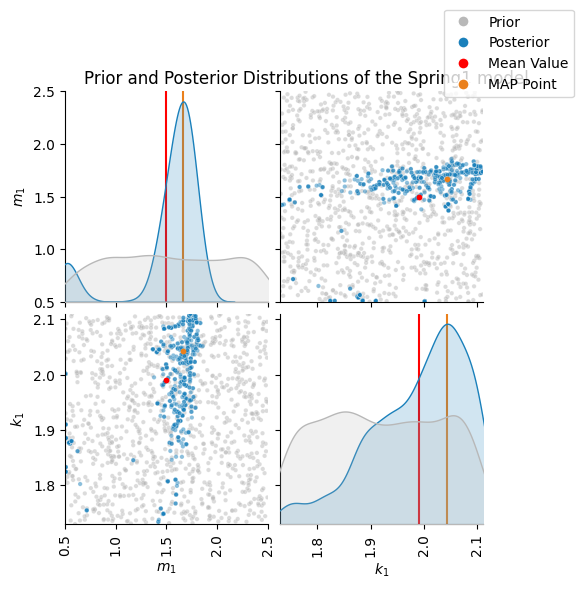

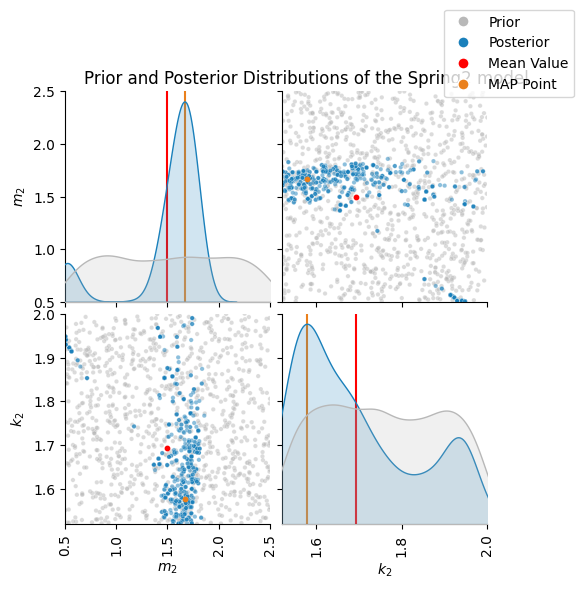

In [ ]:
# Plot the MCMC sampling results along with the mean and MAP points for each model
figs = dt.plot_multimodel_MCMC(j, map_point=True, model_names=['Spring1', 'Spring2'], formatted_param_names=[["$m_{1}$", "$k_{1}$"], ["$m_{2}$", "$k_{2}$"]])

In [ ]:
model_index = 0
map_point, mean, variance, posterior_samples = j.get_data_of_model(model_index)

In [ ]:
map_point

,m1,k1
0,1.668029,2.043467


In [ ]:
mean

,m1,k1
0,1.50026,1.989882


In [ ]:
variance

,m1,k1
0,1.644769,1.961253


In [ ]:
posterior_samples

,m1,k1
0,1.713713,2.096326
1,0.650969,1.802533
2,1.421933,2.045527
3,1.612036,1.924817
4,1.583397,1.979263
...,...,...
635,1.499813,1.989777
636,1.740325,2.022511
637,1.810236,2.064736
638,1.486073,1.944197
